#Import modules

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Comparison of top predicted metabolites per model

In [25]:
path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res'

r2_ridge = pd.read_csv(f'{path}/r2_ridge.csv')
r2_lasso = pd.read_csv(f'{path}/r2_lasso.csv')
r2_elastic = pd.read_csv(f'{path}/r2_elastic.csv')
r2_rf = pd.read_csv(f'{path}/r2_rf.csv')
r2_lgbm = pd.read_csv(f'{path}/r2_lgbm.csv')
r2_xgb = pd.read_csv(f'{path}/r2_xgb.csv')
r2_mlp = pd.read_csv(f'{path}/r2_mlp.csv',)
r2_ensemble = pd.read_csv(f'{path}//r2_ensemble.csv')

spearman_ridge = pd.read_csv(f'{path}/spearman_ridge.csv')
spearman_lasso = pd.read_csv(f'{path}/spearman_lasso.csv')
spearman_elastic = pd.read_csv(f'{path}/spearman_elastic.csv')
spearman_rf = pd.read_csv(f'{path}/spearman_rf.csv')
spearman_lgbm = pd.read_csv(f'{path}/spearman_lgbm.csv')
spearman_xgb = pd.read_csv(f'{path}/spearman_xgb.csv')
spearman_mlp = pd.read_csv(f'{path}/spearman_mlp.csv')
spearman_ensemble = pd.read_csv(f'{path}/spearman_ensemble.csv')

In [26]:
#Comparing r2

def get_list_high_r2_metabolites(r2_df, score_threshold):
  r2_df_top = r2_df[r2_df['R2 Score'] > score_threshold]
  top_metabolites = r2_df_top['Metabolite'].to_list()
  return top_metabolites

In [27]:
r2_threshold = 0.1

ridge_metabolites = get_list_high_r2_metabolites(r2_df = r2_ridge, score_threshold = r2_threshold)
lasso_metabolites = get_list_high_r2_metabolites(r2_df = r2_lasso, score_threshold = r2_threshold)
elastic_metabolites = get_list_high_r2_metabolites(r2_df = r2_elastic, score_threshold = r2_threshold)
rf_metabolites = get_list_high_r2_metabolites(r2_df = r2_rf, score_threshold = r2_threshold)
xgb_metabolites = get_list_high_r2_metabolites(r2_df = r2_xgb, score_threshold = r2_threshold)
lgbm_metabolites = get_list_high_r2_metabolites(r2_df = r2_lgbm, score_threshold = r2_threshold)
mlp_metabolites = get_list_high_r2_metabolites(r2_df = r2_mlp, score_threshold = r2_threshold)
ensemble_metabolites = get_list_high_r2_metabolites(r2_df = r2_ensemble, score_threshold = r2_threshold)

In [28]:
def find_common_elements(lists):
  common_elements = set(lists[0])
  for i in range(1, len(lists)):
    common_elements = common_elements.intersection(lists[i])
  return common_elements

common_r2_high = find_common_elements([ridge_metabolites, lasso_metabolites, elastic_metabolites, rf_metabolites, xgb_metabolites, lgbm_metabolites, mlp_metabolites, ensemble_metabolites])
len(common_r2_high)

38

In [29]:
with open(f'{path}/common_r2_high.txt', 'w') as file:
    for metabolite in common_r2_high:
        file.write(f"{metabolite}\n")

In [30]:
#Comparing spearman's

def get_list_high_spearman_metabolites(spearman_df, score_threshold):
  spearman_df_top = spearman_df[spearman_df['Spearman Coefficient'] > score_threshold]
  top_metabolites = spearman_df_top['Metabolite'].to_list()
  return top_metabolites

In [31]:
spearmans_threshold = 0.3

ridge_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_ridge, score_threshold = spearmans_threshold)
lasso_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_lasso, score_threshold = spearmans_threshold)
elastic_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_elastic, score_threshold = spearmans_threshold)
rf_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_rf, score_threshold = spearmans_threshold)
xgb_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_xgb, score_threshold = spearmans_threshold)
lgbm_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_lgbm, score_threshold = spearmans_threshold)
mlp_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_mlp, score_threshold = spearmans_threshold)
ensemble_metabolites_s = get_list_high_spearman_metabolites(spearman_df = spearman_ensemble, score_threshold = spearmans_threshold)

In [32]:
common_spearman_high = find_common_elements([ridge_metabolites_s, lasso_metabolites_s, elastic_metabolites_s, rf_metabolites_s, xgb_metabolites_s, lgbm_metabolites_s, mlp_metabolites_s, ensemble_metabolites_s])
len(common_spearman_high)

58

In [33]:
with open(f'{path}/common_spearmans_high.txt', 'w') as file:
    for metabolite in common_spearman_high:
        file.write(f"{metabolite}\n")

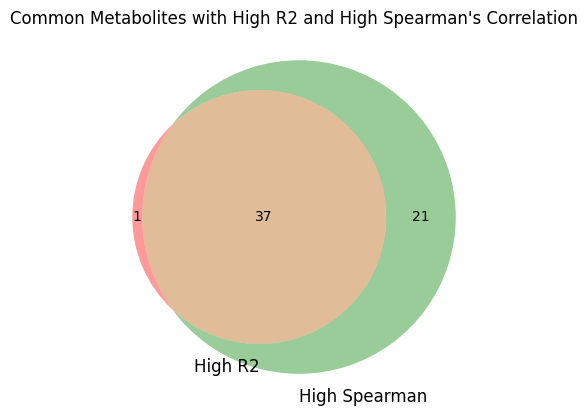

In [34]:
#Compare Spearman's top and R2 top

from matplotlib_venn import venn2

venn2([set(common_r2_high), set(common_spearman_high)], set_labels = ('High R2', 'High Spearman'))
plt.title("Common Metabolites with High R2 and High Spearman's Correlation")
plt.savefig(f'{path}/venn_common_r2_spearman.svg', bbox_inches = 'tight')
plt.show()

In [35]:
common_elements = set(common_r2_high).intersection(common_spearman_high)
with open(f'{path}/common_r2_spearman_high.txt', 'w') as file:
    for metabolite in common_elements:
        file.write(f"{metabolite}\n")

In [36]:
r2_data = pd.concat([
                     r2_ridge.set_index('Metabolite').rename(columns = {'R2 Score' : 'Ridge'}),
                     r2_lasso.set_index('Metabolite').rename(columns = {'R2 Score' : 'Lasso'}),
                     r2_elastic.set_index('Metabolite').rename(columns = {'R2 Score' : 'Elastic Net'}),
                     r2_rf.set_index('Metabolite').rename(columns = {'R2 Score' : 'Random Forest Regressor'}),
                     r2_xgb.set_index('Metabolite').rename(columns = {'R2 Score' : 'XGBoost Regressor'}),
                     r2_lgbm.set_index('Metabolite').rename(columns = {'R2 Score' : 'LighGBM Regressor'}),
                     r2_mlp.set_index('Metabolite').rename(columns = {'R2 Score' : 'MLP Regressor'}),
                     r2_ensemble.set_index('Metabolite').rename(columns = {'R2 Score' : 'Ensemble'})
                     ], axis = 'columns')
r2_data

,Ridge,Lasso,Elastic Net,Random Forest Regressor,XGBoost Regressor,LighGBM Regressor,MLP Regressor,Ensemble
Metabolite,,,,,,,,
1-methylnicotinamide,0.614567,0.563711,0.604839,0.494592,0.383186,0.543845,0.510193,0.712419
phosphocreatine,0.500982,0.422342,0.465894,0.389168,0.316404,0.386113,0.275608,0.637276
C20:5 CE,0.423003,0.399814,0.405979,0.335247,0.273543,0.327094,0.338158,0.684787
C20:4 CE,0.394206,0.389508,0.385566,0.294505,0.299549,0.266797,0.323851,0.712735
C18:1 CE,0.377376,0.343014,0.354668,0.303635,0.256128,0.322598,0.335985,0.654544
...,...,...,...,...,...,...,...,...
erythrose-4-phosphate,-0.042653,-0.055289,-0.038186,-0.024755,-0.048121,-0.099781,-0.038407,0.508380
homocysteine,-0.052971,-0.003255,-0.027344,-0.002915,-0.099452,-0.101186,0.003881,0.673174
serotonin,-0.061540,-0.018081,-0.040171,-0.006393,-0.210732,-0.076392,-0.005619,0.592959


<ipython-input-37-12fe9e80e694>:7: UserWarning: 
The palette list has fewer values (6) than needed (225) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x="Model", y="R2", data=df_long, hue="Metabolite",  marker="o",  alpha=0.6, legend = False, size = 5, palette = palette)


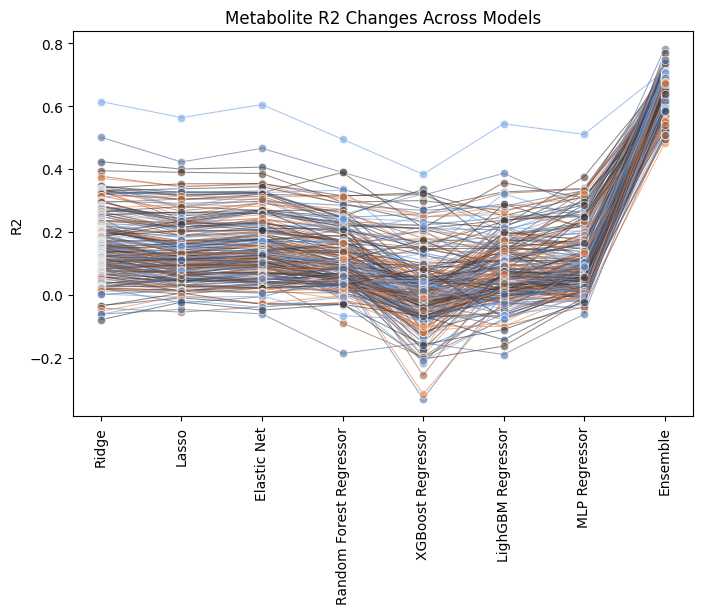

In [37]:
df_long = r2_data.reset_index().melt(id_vars="Metabolite", var_name="Model", value_name="R2")
df_long.rename(columns={"Metabolite": "Metabolite"}, inplace=True)

# Plot
plt.figure(figsize=(8, 5))
palette = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=False)
sns.lineplot(x="Model", y="R2", data=df_long, hue="Metabolite",  marker="o",  alpha=0.6, legend = False, size = 5, palette = palette)
plt.xticks(rotation = 90)
plt.title("Metabolite R2 Changes Across Models")
plt.xlabel('')
plt.savefig(f'{path}/R2_changes_across_models.svg', bbox_inches = 'tight')
plt.show()

In [38]:
spermans_data = pd.concat([
                            spearman_ridge.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'Ridge'}),
                            spearman_lasso.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'Lasso'}),
                            spearman_elastic.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'Elastic Net'}),
                            spearman_rf.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'Random Forest Regressor'}),
                            spearman_xgb.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'XGBoost Regressor'}),
                            spearman_lgbm.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'LighGBM Regressor'}),
                            spearman_mlp.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'MLP Regressor'}),
                            spearman_ensemble.set_index('Metabolite').rename(columns = {'Spearman Coefficient' : 'Ensemble'})
                            ], axis = 'columns')
spermans_data

,Ridge,Lasso,Elastic Net,Random Forest Regressor,XGBoost Regressor,LighGBM Regressor,MLP Regressor,Ensemble
Metabolite,,,,,,,,
1-methylnicotinamide,0.797898,0.766293,0.793128,0.712246,0.642361,0.742949,0.723367,0.848803
phosphocreatine,0.639882,0.545249,0.592942,0.523807,0.575356,0.506501,0.485294,0.822144
creatine,0.634379,0.537823,0.579696,0.480556,0.336984,0.458562,0.444772,0.791277
C20:5 CE,0.631562,0.612749,0.615472,0.537148,0.531438,0.529330,0.559512,0.829448
C20:3 CE,0.611793,0.577726,0.587497,0.465304,0.407996,0.496968,0.508882,0.837820
...,...,...,...,...,...,...,...,...
malondialdehyde,0.101464,0.142011,0.131220,0.095833,0.007706,0.056551,0.053326,0.747815
asparagine,0.096581,0.095387,0.112588,0.174253,0.080498,0.181258,0.097032,0.777125
serotonin,0.052685,0.080635,0.063826,0.080858,-0.101357,0.017276,0.149188,0.787130


<ipython-input-39-ae4ffd13ff9d>:8: UserWarning: 
The palette list has fewer values (6) than needed (225) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x="Model", y="Spearman's Coefficient", data=df_long, hue="Metabolite",  marker="o",  alpha=0.6, legend = False, size = 5, palette = palette )


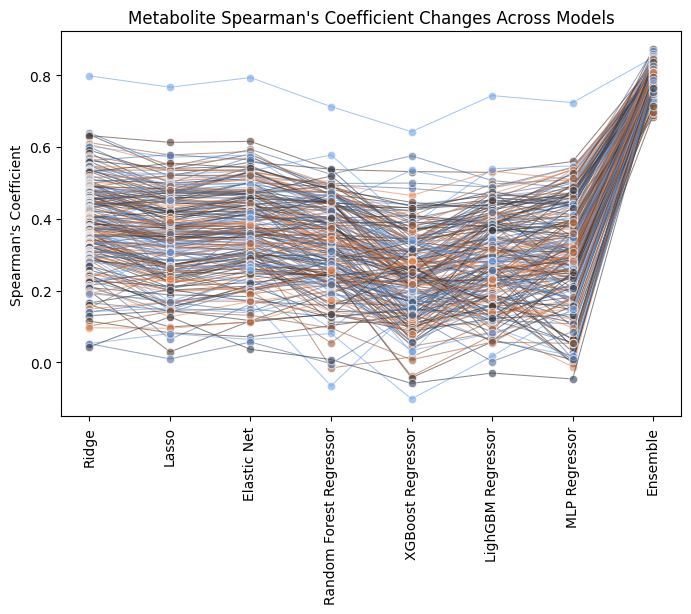

In [39]:
df_long = spermans_data.reset_index().melt(id_vars="Metabolite", var_name="Model", value_name="Spearman's Coefficient")
df_long.rename(columns={"Metabolite": "Metabolite"}, inplace=True)


# Plot
plt.figure(figsize=(8, 5))
palette = sns.diverging_palette(250, 30, l=65, center="dark", as_cmap=False)
sns.lineplot(x="Model", y="Spearman's Coefficient", data=df_long, hue="Metabolite",  marker="o",  alpha=0.6, legend = False, size = 5, palette = palette )
plt.xticks(rotation = 90)
plt.title("Metabolite Spearman's Coefficient Changes Across Models")
plt.xlabel('')
plt.savefig(f'{path}/Spearmans_changes_across_models.svg', bbox_inches = 'tight')
plt.show()